# EvidencIA - treinamento, execução, avaliação e EDA

Entrega de 09/10/2026. Este notebook foi executado e preserva as saídas. Reproduza a partir da pasta do pacote, com `pip install -r requirements-notebook.txt` em ambiente virtual. Os dados são o corpus local do repositório, não um gold set factual independente. Classes `fake`/`true` são rótulos locais de treinamento; o score não é probabilidade de veracidade nem calibração empírica.

O teste fixo é separado antes do ajuste do vocabulário. Não ajustamos parâmetros para maximizar o resultado observado. Um baseline majoritário permite interpretar o ganho. Os gráficos e métricas são calculados a partir dos arquivos incluídos.

In [1]:
from pathlib import Path
import sys
import json
import hashlib
import pandas as pd
import matplotlib.pyplot as plt

locations = [Path.cwd(), *Path.cwd().parents]
BASE = next(p for p in locations if (p / "datasets/training_local.csv").exists() or (p / "backend/ml/datasets/training_local.csv").exists())
is_repo = (BASE / "backend/ml/datasets/training_local.csv").exists()
DATA = BASE / ("backend/ml/datasets/training_local.csv" if is_repo else "datasets/training_local.csv")
OUTPUT = BASE / ("work/model-evaluation" if is_repo else ".")
(OUTPUT / "modelo").mkdir(parents=True, exist_ok=True)
(OUTPUT / "eda").mkdir(parents=True, exist_ok=True)
sys.path.insert(0, str(BASE / ("backend" if is_repo else "codigo")))
from ml.classifier.model import ClaimClassifier  # noqa: E402
from ml.classifier.dataset import TrainingSample  # noqa: E402
from ml.classifier.evaluator import evaluate_model  # noqa: E402
SEED = 42
print("Semente:", SEED, "SHA256 dos dados:", hashlib.sha256(DATA.read_bytes()).hexdigest())

Semente: 42 SHA256 dos dados: 379f725f5568bea2c42c8aeff3d0aa78908086ad5735828a29fe68d53d818246


## Preparação e EDA

Verificamos campos vazios, domínio dos rótulos, duplicatas e sobreposição literal entre treino e teste. A origem declarada não equivale a proveniência certificada. Normalização de texto e TF-IDF ficam dentro do vetorizador do modelo; ele é ajustado apenas no treino.

In [2]:
df = pd.read_csv(DATA, keep_default_na=False)
assert not (df[["text", "label", "split"]] == "").any().any()
assert set(df.label) == {"fake", "true"}
assert set(df.split) == {"train", "test"}
df["words"] = df.text.str.split().str.len()
train_df = df[df.split == "train"].copy()
test_df = df[df.split == "test"].copy()
def normalize(t):
    return " ".join(t.casefold().split())
overlap = set(train_df.text.map(normalize)) & set(test_df.text.map(normalize))
assert not overlap, "Há vazamento literal entre treino e teste"
eda = {"rows": len(df), "train": len(train_df), "test": len(test_df), "labels": df.label.value_counts().to_dict(), "categories": df.category.value_counts().to_dict(), "sources_declared": df.source_declared.value_counts().to_dict(), "duplicate_texts": int(df.text.map(normalize).duplicated().sum()), "train_test_literal_overlap": len(overlap), "word_count": df.words.describe().to_dict()}
print(json.dumps(eda, ensure_ascii=False, indent=2))
(OUTPUT / "eda/summary.json").write_text(json.dumps(eda, ensure_ascii=False, indent=2))

{
  "rows": 139,
  "train": 112,
  "test": 27,
  "labels": {
    "fake": 70,
    "true": 69
  },
  "categories": {
    "saúde": 61,
    "ciência": 24,
    "economia": 23,
    "política": 18,
    "sociedade": 11,
    "educação": 1,
    "tecnologia": 1
  },
  "sources_declared": {
    "FactChecks.br": 89,
    "Fake.br": 15,
    "Fake.br (NILC/USP)": 10,
    "FactChecks.br (Agência Lupa)": 6,
    "FactChecks.br (Aos Fatos)": 6,
    "FactChecks.br (G1 Fato ou Fake)": 6,
    "FactChecks.br (Boatos.org)": 3,
    "FactChecks.br (UOL Confere)": 2,
    "FactChecks.br (Ministério da Saúde / Fiocruz)": 2
  },
  "duplicate_texts": 0,
  "train_test_literal_overlap": 0,
  "word_count": {
    "count": 139.0,
    "mean": 15.251798561151078,
    "std": 2.675962579567265,
    "min": 9.0,
    "25%": 14.0,
    "50%": 15.0,
    "75%": 17.0,
    "max": 22.0
  }
}


853

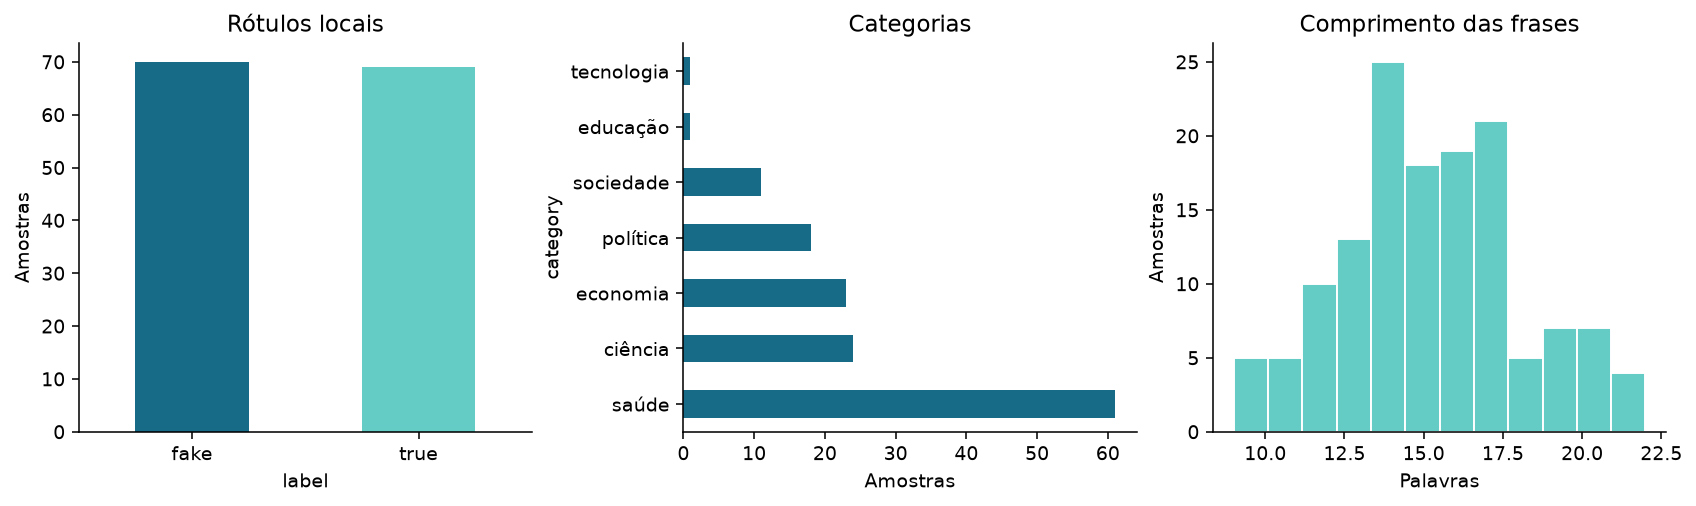

In [3]:
plt.rcParams.update({"figure.dpi": 140, "font.size": 10, "axes.spines.top": False, "axes.spines.right": False})
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), constrained_layout=True)
df.label.value_counts().plot.bar(ax=axes[0], color=["#176B87", "#64CCC5"], rot=0)
axes[0].set(title="Rótulos locais", ylabel="Amostras")
df.category.value_counts().plot.barh(ax=axes[1], color="#176B87")
axes[1].set(title="Categorias", xlabel="Amostras")
axes[2].hist(df.words, bins=12, color="#64CCC5", edgecolor="white")
axes[2].set(title="Comprimento das frases", xlabel="Palavras", ylabel="Amostras")
fig.savefig(OUTPUT / "eda/distribuicoes.png", bbox_inches="tight")
plt.show()

## Abordagem e treinamento

Multinomial Naive Bayes com TF-IDF, unigramas/bigramas e características de estilo. Critérios: execução offline, baixo custo, explicações por atributos e serialização JSON sem executar pickle. `alpha=0.5` e limiar de abstenção `0.60` preservam a configuração preexistente; não foram selecionados pelo desempenho neste teste. Não é um modelo de prova factual. O modelo de avaliação e o modelo entregue são o mesmo, treinado somente na partição de treino.

In [4]:
model = ClaimClassifier(alpha=0.5, acceptance_threshold=0.60)
model.train(train_df.text.tolist(), train_df.label.tolist())
model_path = OUTPUT / "modelo/claim_classifier.json"
model.save(str(model_path))
loaded = ClaimClassifier.load(str(model_path))
test_samples = [TrainingSample(r.text, r.label, r.category, r.source_declared) for r in test_df.itertuples()]
metrics = evaluate_model(loaded, test_samples)
majority = train_df.label.value_counts().idxmax()
baseline_accuracy = float((test_df.label == majority).mean())
metrics["majority_baseline"] = {"label": majority, "accuracy": baseline_accuracy}
metrics["protocol"] = {"split_seed": SEED, "train": len(train_df), "test": len(test_df), "tuning_on_test": False, "scope": "local linguistic corpus; no independent factual validation"}
(OUTPUT / "modelo/metrics.json").write_text(json.dumps(metrics, ensure_ascii=False, indent=2))
print("Acurácia:", metrics["accuracy"], "Macro F1:", metrics["macro_f1"], "Baseline:", baseline_accuracy)
print(pd.DataFrame(metrics["classes"]).T.to_string())
print(pd.DataFrame(metrics["acceptance_curve"]).to_string(index=False))

Acurácia: 0.6667 Macro F1: 0.6592 Baseline: 0.5185185185185185
      precision  recall      f1
fake     0.6471  0.7857  0.7097
true     0.7000  0.5385  0.6087
 threshold  accepted_count  total_count  acceptance_rate_pct  abstention_rate_pct  precision_on_accepted_pct  error_rate_on_accepted_pct
      0.50              27           27                100.0                  0.0                       66.7                        33.3
      0.55              22           27                 81.5                 18.5                       72.7                        27.3
      0.60              18           27                 66.7                 33.3                       83.3                        16.7
      0.65              10           27                 37.0                 63.0                       90.0                        10.0
      0.70               6           27                 22.2                 77.8                       83.3                        16.7
      0.75         

## Métricas e análise de erro

Acurácia: proporção de acertos. Precisão e recall por classe separam alarmes falsos de omissões; macro F1 dá o mesmo peso às classes. A matriz de confusão usa `fake` como classe positiva. Cobertura e taxa de abstenção são reportadas por limiar. Quando nenhuma previsão é aceita, precisão seletiva é indefinida (`null`), nunca 100%. Os limiares abaixo são análise descritiva, não ajuste no teste.

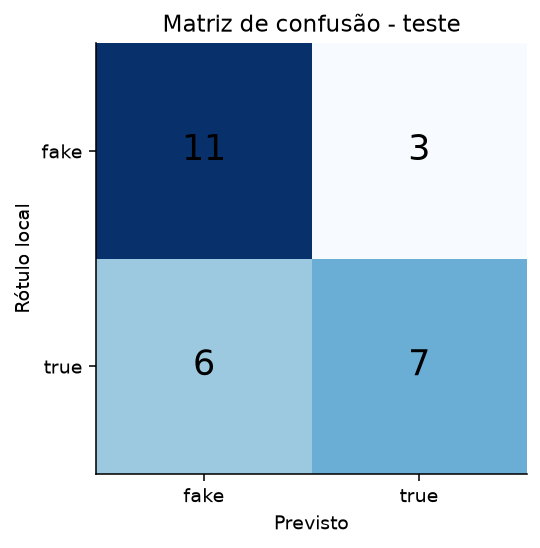

Erros observados:
        id                                                                                                                           text label predicted  score  correct
local-0001             O governo anunciou redução de impostos para pequenas empresas segundo relatório oficial do Ministério da Economia.  true      fake 0.5920    False
local-0018                   O programa Estação SUS e a atenção primária promovem saúde e prevenção de doenças nos municípios brasileiros  true      fake 0.5083    False
local-0050                                 O tabagismo ativo é a principal causa evitável de câncer de pulmão e doenças cardiovasculares.  true      fake 0.6091    False
local-0064                                     O Produto Interno Bruto mede a soma de todos os bens e serviços finais produzidos no país.  true      fake 0.5555    False
local-0077                                   Constituição Federal de 1988 foi revogada por decisão monocrática de tribunal internaci

In [5]:
predictions = [loaded.predict(t, threshold=0.5) for t in test_df.text]
pred_df = test_df[["id", "text", "label"]].copy()
pred_df["predicted"] = [p["dominant_label"] for p in predictions]
pred_df["score"] = [p["confidence"] for p in predictions]
pred_df["correct"] = pred_df.label == pred_df.predicted
pred_df.to_csv(OUTPUT / "modelo/test_predictions.csv", index=False)
cm = metrics["confusion_matrix"]
matrix = [[cm["tp"], cm["fn"]], [cm["fp"], cm["tn"]]]
fig, ax = plt.subplots(figsize=(4.5, 3.8), constrained_layout=True)
ax.imshow(matrix, cmap="Blues")
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(matrix[i][j]), ha="center", va="center", fontsize=18)
ax.set(xticks=[0,1], yticks=[0,1], xticklabels=["fake", "true"], yticklabels=["fake", "true"], xlabel="Previsto", ylabel="Rótulo local", title="Matriz de confusão - teste")
fig.savefig(OUTPUT / "eda/confusao.png", bbox_inches="tight")
plt.show()
print("Erros observados:")
print(pred_df[~pred_df.correct].to_string(index=False))

## Carregar e executar o modelo entregue

O arquivo JSON inclui vocabulário, pesos e parâmetros. Carregar não executa código do arquivo de modelo; as classes Python necessárias estão incluídas no pacote. A inferência deve ser interpretada como padrão linguístico. Fontes documentais independentes continuam necessárias para investigar a alegação.

In [6]:
example = "A vacina passou por estudos clínicos e foi aprovada pela agência reguladora."
result = loaded.predict(example)
assert result == model.predict(example)
print(json.dumps(result, ensure_ascii=False, indent=2))
print("Modelo salvo e recarregado; equivalência de inferência verificada.")

{
  "label": "true",
  "dominant_label": "true",
  "confidence": 0.7508,
  "accepted": true,
  "threshold": 0.6,
  "probabilities": {
    "fake": 0.2492,
    "true": 0.7508
  },
  "top_features": [
    [
      "style_credibility_score",
      0.3523
    ],
    [
      "aprovada",
      0.1776
    ],
    [
      "clinicos",
      0.1762
    ],
    [
      "estudos",
      0.17
    ],
    [
      "passou",
      0.1691
    ]
  ]
}
Modelo salvo e recarregado; equivalência de inferência verificada.


## Limitações e próximos critérios de qualidade

O corpus é pequeno e contém exemplos curados/fixtures, com origem externa não comprovada individualmente. Ausência de duplicação literal não elimina sobreposição semântica. O teste mede classificação neste corpus, não generalização a vídeos, recuperação factual, calibração ou concordância entre anotadores. O gold set de retrieval incluído está sem anotações humanas; não calculamos métricas inexistentes. Para avaliação empírica, adicionar conjunto independente, validar licenças/proveniência e registrar anotações e concordância. Aprovação humana autoriza o trabalho; ela não altera os dados observados.